## Notebook to compare the hough circle transform against the iterative paper programs method.
Both seem to be promising and timely methods, so let's consider how much accuracy gain we get from each, and if there are any clear correlations or areas where one method outperforms the other.

In [42]:
## Import cell

import pandas as pd
import matplotlib.pyplot as plt
import random
import seaborn as sns
import puck.experiments.best_thresholding.hough_iterative as hi
import numpy as np

`output_file_dict` holds the dictionary produced by `hi.main()`, which runs an arbitrary hough circle transform, and iterative approach on the full data set. 

The Keys should be:
- `bigpicture0`, `bigpicture1`, which are the paths to the full .csvs with details about the images and the blob count and accuracy and time.
- `output_timing`, is the path to .txt of information about the timing for these runs.
- `results` is an array of two dictionaries, the first dictionary for the hough approach , the second dictionary for the iterative approach. This can also be found by getting one of the dictionary and checking the value of the `choice` key within it. 
    - These dictionaries hold the average time and median time per run and the accuracy of the methods. Accordingly their keys are:
        - `choice`
        - `accuracy`
        - `avgTimeToDetect`
        - `medianTimeToDetect`   

The `hi.main()` function has several path parameters, importantly the `adjustment_on` which is default set to fault. The default adjustment is "..\" which takes you up a folder and then looks relative to that folder. I turn it on for the notebook, but keep it off when I'm using the .py file in the CLI. Similarly there is a `cli_output` parameter, I keep this on by default, but you can turn it off in the notebook if it bothers you.

In [20]:
output_file_dict= hi.main(adjustment_on= True)

{'choice': 'houghCircle', 'accuracy': 0.4791666666666667, 'avgTimeToDetect': 9619403.464583334, 'medianTimeToDetect': 9606687.5}
{'choice': 'iterative', 'accuracy': 0.9375, 'avgTimeToDetect': 34372388.86666667, 'medianTimeToDetect': 33685937.5}
The summary statistics are saved in ../output/experimental_results/hough_iterative as .csvs 
                 The timing info is saved as ../output/timing_results/timingResults_hough_iterative_20260515_150647.txt


Double check the dictionary returns what you expect. See markdown cell prior for what you should be getting back.

In [21]:
output_file_dict

{'bigpicture0': '../output/experimental_results/hough_iterative/houghCircle_results.csv',
 'bigpicture1': '../output/experimental_results/hough_iterative/iterative_results.csv',
 'output_timing': '../output/timing_results/timingResults_hough_iterative_20260515_150647.txt',
 'results': [{'choice': 'houghCircle',
   'accuracy': 0.4791666666666667,
   'avgTimeToDetect': 9619403.464583334,
   'medianTimeToDetect': 9606687.5},
  {'choice': 'iterative',
   'accuracy': 0.9375,
   'avgTimeToDetect': 34372388.86666667,
   'medianTimeToDetect': 33685937.5}]}

Get the .csv files and turn them into Pandas Dataframes.

In [22]:
hough = pd.read_csv(output_file_dict.get("bigpicture0"))
iterative = pd.read_csv(output_file_dict.get("bigpicture1"))

Inspect the .csv file heads to make sure you're getting back the same type of data across both, and that the first column is a file name. This will be useful later on if/when you slice up the file name to create new columns within the dataframe. 

In [23]:
hough.head()

,Unnamed: 0,0,1,2,3,4
0,../data/images_copy/custom/davids/high/A/custo...,8,True,False,23135792,"[0.7071067811865476, 0.7071067811865476, 0.707..."
1,../data/images_copy/custom/davids/high/A/custo...,7,True,False,13756083,"[0.7071067811865476, 0.7071067811865476, 0.707..."
2,../data/images_copy/custom/davids/high/A/custo...,7,True,False,10022083,"[0.7071067811865476, 1.5811388300841898, 1.581..."
3,../data/images_copy/custom/davids/high/A/custo...,9,True,False,10936959,"[0.7071067811865476, 1.5811388300841898, 1.581..."
4,../data/images_copy/custom/davids/high/A/custo...,9,True,False,9674875,"[1.5811388300841898, 1.5811388300841898, 1.581..."


In [24]:
iterative.head()

,Unnamed: 0,0,1,2,3,4
0,../data/images_copy/custom/davids/high/A/custo...,4,True,True,36137208,"[0.0, 1.0, 1.0, 1.0]"
1,../data/images_copy/custom/davids/high/A/custo...,5,True,False,39341417,"[1.0, 1.0, 1.0, 2.23606797749979, 906.52082160..."
2,../data/images_copy/custom/davids/high/A/custo...,4,True,True,34524500,"[0.0, 1.0, 1.0, 1.4142135623730951]"
3,../data/images_copy/custom/davids/high/A/custo...,4,True,True,50329583,"[1.0, 1.0, 2.0, 2.23606797749979]"
4,../data/images_copy/custom/davids/high/A/custo...,4,True,True,34759833,"[1.0, 1.0, 1.4142135623730951, 2.0]"


Get the results dictionaries by getting the value of the key `results` and then index the returned array with 0 and 1 for hough and iterative respectively. Can also inspect the `choice` keys for each dictionary returned in the array, to double check this, but 0 and 1 should return the correct dictionaries.

In [25]:
results = output_file_dict.get("results")
hough_results = results[0]
iterative_results = results[1]

Inspect the `hough_results` dictionary, you should get back the previously mentioned keys, with values of a string, some value between 0,1 and very large numbers for the nanoseconds.

In [26]:
hough_results

{'choice': 'houghCircle',
 'accuracy': 0.4791666666666667,
 'avgTimeToDetect': 9619403.464583334,
 'medianTimeToDetect': 9606687.5}

Divide the average and median times to detect by 1,000,000 to convert the units from nanoseconds (ns) to miliseconds (ms). Remember that we want 33ms or less for real time processing of the papers.

In [27]:
hough_results.get('avgTimeToDetect') / 1_000_000

9.619403464583334

In [28]:
hough_results.get('medianTimeToDetect') / 1_000_000

9.6066875

Repeat this process for iterative results.

In [29]:
iterative_results.get('avgTimeToDetect') / 1_000_000

34.37238886666667

In [30]:
iterative_results.get('medianTimeToDetect') / 1_000_000

33.6859375

The hough transform is significantly faster than the iterative approach, at 9ms compared to about 33ms. We can compare accuracy but because the hough method is arbitrarily parameterized, we can expect that it's somewhat inaccurate, particularly relative to the iterative method which has been the most promising in time and accuracy thus far.

In [31]:
hough_results.get("accuracy")

0.4791666666666667

In [32]:
iterative_results.get("accuracy")

0.9375

The iterative is much more accurate, but the massive speedup from hough warrents greater investigation to see if a better parameterized method would lead to a higher accuracy than .48

Let's now check if there is any specific pattern that emerges in terms of the encoding permutation and the chosen methods. Using `cleaner()`, we can cut up the current dataframes into some that are more human readable and seperate out the permutations. This returns those dataframes as the same as the original paths just with "_cleaned.csv" affixed to it.

In [33]:
def cleaner(path):
    print(path)
    df = pd.read_csv(path)
    df.columns =["name","blobCount", "closeEnough", "closeCount4", "time", "points"]
    df[['dots', 'data','images','palette', 'loc', 'height', 'set', "path"]] = df.name.str.split("/",expand=True)
    df = df.drop(["dots", "data", "images", "name",], axis = 1)
    df["count4"] =(df["blobCount"] == 4)
    df_reordered = df.loc[:, ["palette", "loc", "height", "set", 'blobCount', 'closeEnough', 'count4', 'closeCount4', "time","points", "path"]] 
    df_reordered.to_csv(path[:-4] + "_cleaned.csv")
    return (path[:-4] + "_cleaned.csv")


In [ ]:
#Grab the cleaned csv paths
hough_cleaned_path= cleaner(output_file_dict.get("bigpicture0"))
iterative_cleaned_path= cleaner(output_file_dict.get("bigpicture1"))

../output/experimental_results/hough_iterative/houghCircle_results.csv
../output/experimental_results/hough_iterative/iterative_results.csv


In [ ]:
#Grab the dataframes using the cleaned csv paths.
hough_cleaned = pd.read_csv(hough_cleaned_path)
iterative_cleaned = pd.read_csv(iterative_cleaned_path)

Next let's make a strip/swarm plot of the blob counts for hough and the permutations to see if there's any pattern that emerges, or if we can see if there is any clustering occuring based on the palettes, by colour coding the data points as they're graphed.

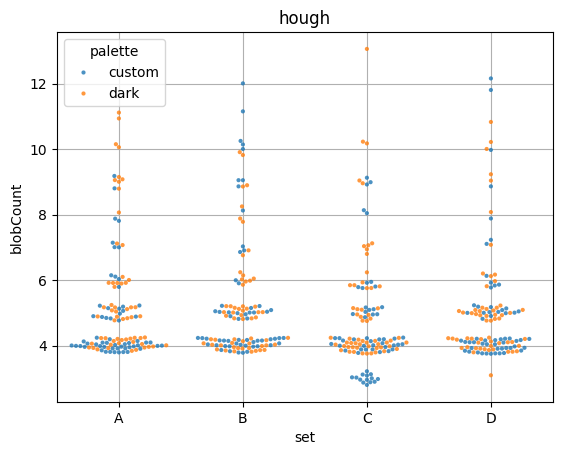

In [36]:
random.seed(2026)
adjust= [random.uniform(-.25,.25) for _ in range(480)]
hough_cleaned["blobCount"] = hough_cleaned["blobCount"] + adjust
sns.swarmplot(data=hough_cleaned, x="set", y="blobCount", hue= "palette", alpha = .8, size = 3)
plt.title("hough")
plt.grid() 
plt.show()

It seems that custom permutation C has slightly inaccurate responses, as they have a cluster of the custom palette at only 3 blobs found. However across the permutations, in the upper range of blobs, while the distribution is focused around 4, they reach as high as 13 for their blob count and seem to be right tailed distributions (or in this case top tailed). There seems to be no other clear palette clusterings, everything looks very intermixed, so the hough system isn't preferentially treating either the custom or dark palette.

Let's consider a histogram of how close the found hough values were to the ground truth centres of the circles. 

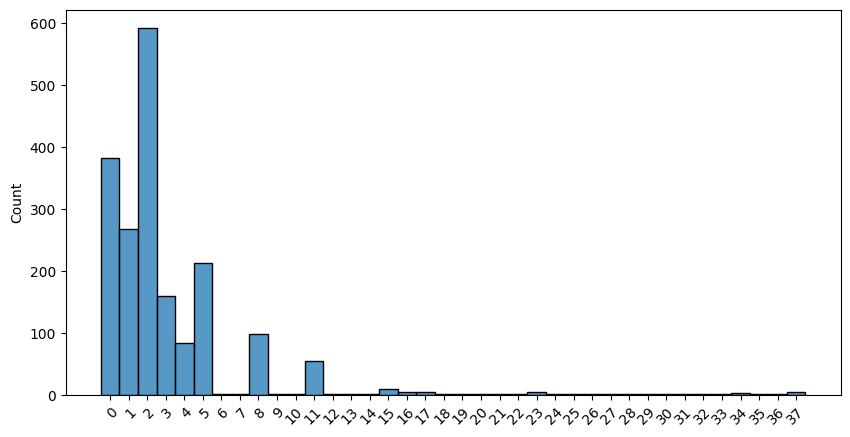

In [69]:
possible_dist = []
for x in hough_cleaned["points"]:
    x = x.lstrip("[")
    x= x.rstrip("]")
    dists = x.split(",")
    first_four = dists[0:4]
    for d in first_four:
        possible_dist.append(d)

plt.figure(figsize=(10,5))
ax = sns.histplot(data=possible_dist)
x_ticks = ax.get_xticks()
ax.set_xticks(x_ticks)
ax.set_xticklabels(np.round((x_ticks), 0))
plt.xticks(rotation=45,ha ="right", rotation_mode = "anchor")
plt.show()

We see a pretty strong clustering around 0 with only a few outliers, this is a good sign, that at least we aren't detecting blobs very far off from the ground truth we've established.

Let's consider the iterative method now, and how that is distributed based on permutation and palette.

/Users/jdreiling/Desktop/puck/puck/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jdreiling/Desktop/puck/puck/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 18.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jdreiling/Desktop/puck/puck/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 10.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jdreiling/Desktop/puck/puck/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 24.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarni

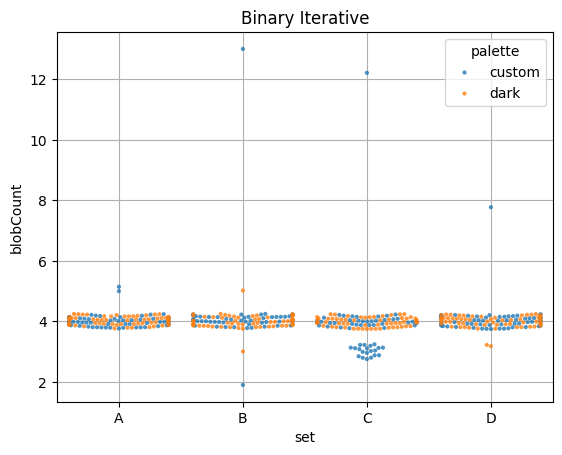

In [38]:
random.seed(2026)
adjust= [random.uniform(-.25,.25) for _ in range(480)]
iterative_cleaned["blobCount"] = iterative_cleaned["blobCount"] + adjust
sns.swarmplot(data=iterative_cleaned, x="set", y="blobCount", hue= "palette", alpha = .8, size = 3)
plt.title("Binary Iterative")
plt.grid() 
plt.show()

We see a much clearer clustering around 4, and a repeat of that custom c permutation lacking all four dots. Since this is the more accurate of the methods, it makes sense that it gets the correct blob count. The custom C permutation merits more consideration as a possible poor case for dot detection. Though maybe there's something within the data that is a real problem given both methods seem to fail..